# Module 5 — Complete Machine Learning System

This module builds a complete machine learning system whose purpose is to predict the probability that a selected student type is at a specific campus location at a given time. The problem is not treated as a single direct classification task over every possible room. Instead, it is decomposed into two connected parts. First, the system predicts the probability of a student being in a main campus location based on student type, time slot, and a few derived features. Second, it estimates the probability of an inner location given the main location, student type, and time slot. The final frontend probability is then computed as the product of these two terms:

\[
P(\text{main, inner} \mid \text{type, time}) =
P(\text{main} \mid \text{type, time}) \cdot
P(\text{inner} \mid \text{main, type, time})
\]

This design makes the full system more interpretable and better aligned with the real campus structure, where buildings contain different rooms and the prediction process naturally has two levels.

---

## Reproducibility

The first step in the system is setting a fixed random seed. This is important because the project depends on random processes in multiple places, including synthetic data generation, train-validation-test splitting, and some model training procedures. By fixing the seed, the dataset and experimental results become reproducible. This allows the same code to generate the same output every time, which is especially useful when comparing models fairly or discussing results in a report.

---

## Frontend Schema and Prediction Space

The next section defines the schema of the final system. This includes the valid student types, time slots, main locations, and inner locations. This is an important design decision because the machine learning pipeline is not built in isolation. It is built for a frontend-facing application where a user will choose values from dropdown menus and request probability estimates.

The three student types are Regular Student, Copa, and Athlete. The time variable is broken into specific campus time intervals such as 07:00–08:00, 08:00–09:30, and so on. The location system is hierarchical. Main locations are the buildings or broad campus areas, such as LawrenceHall, StudentCenter, Library, or PlayHouse. Each main location contains one or more inner locations, such as DanceStudios inside LawrenceHall or Gym inside StudentCenter.

This hierarchy matters because it defines the output space of the system. Instead of predicting a flat list of unrelated places, the system reflects the structure of the real environment. That is why the final prediction is naturally split into a main-location model and a conditional inner-location model.

---

## Synthetic World Model for Data Generation

Because this project does not use a real campus-tracking dataset, it constructs a synthetic world model that serves as ground truth for supervised learning. This is one of the most important design choices in the whole module. The machine learning models can only learn patterns that exist in the training data, so the synthetic generator must encode realistic and meaningful behavior.

The code defines weighted distributions for main locations conditioned on student type and time slot. These weights reflect assumptions about where athletes, Copa students, and regular students are more likely to be during different parts of the day. For example, athletes may be more likely to appear in VillagePark or StudentCenter at certain times, while Copa students may be more likely to appear in PlayHouse or BoulevardStudios. Regular students are more likely to appear in academic spaces such as ThayerHall, WestPenn, or the Library during class-oriented hours.

A second set of conditional distributions governs inner locations. Once a main location is selected, the system uses student-type-specific weights to choose the room inside that building. For example, an athlete in StudentCenter is more likely to be in the Gym or with AthleteTrainers, while a Copa student in PlayHouse is more likely to be in ActingStudios or FilmStudios.

This synthetic world model acts as the hidden process that generates labeled data. In other words, it defines the probability structure that the supervised models are trying to learn.

---

## Sampling Functions

After defining the synthetic distributions, the code implements helper functions that sample from those distributions. The weighted-choice function takes a dictionary of weights and selects an outcome proportionally to those weights. This is used first to sample the main location from the appropriate time-and-student-type distribution, and then to sample the inner location from the conditional distribution associated with that building.

If no specific conditional weights are provided for a student type inside a particular main location, the system falls back to a uniform choice among the valid inner rooms for that building. This fallback is a practical system-design detail because it ensures that every query remains defined, even when the training assumptions are incomplete. It prevents the system from breaking in sparse or underspecified cases.

---

## Data Generation

Using the synthetic world model, the code generates a dataset of 25,000 samples. Each sample represents one simulated student-time observation and includes the following fields: student type, time slot, time index, an indicator for whether the time slot is the early athlete hour, an indicator for whether the student-type/time combination is valid, the main location, and the inner location.

The derived features are especially important. The raw categorical features student type and time slot already contain useful information, but the code also introduces numeric and logical features that make the learning task more expressive. The time index provides an ordered numerical representation of time, which may help some models detect temporal progression. The early-athlete-hour variable highlights the special early slot. The validity feature explicitly marks whether a student type appears in a logically valid situation, such as preventing non-athletes from being treated as normal cases during the early athlete-only hour.

This means the dataset is not just a direct dump of categorical values. It is a feature-engineered dataset designed to help models distinguish patterns more clearly.

---

## Part 1 — Learning Setup

The formal supervised learning problem is defined next. The target variable is the main location. The model is asked to learn:

\[
P(\text{main location} \mid \text{student type, time slot, derived features})
\]

The selected feature set includes student type, time slot, time index, early-athlete-hour flag, and validity flag. These features are reasonable because they are available before prediction time and they align with the behavioral logic of the synthetic world.

The data is split into training, validation, and test sets using a 60/20/20 structure. This is good experimental practice. The training set is used to fit models, the validation set is used to compare and tune them, and the test set is held back for the final unbiased evaluation. Stratified splitting is used so that the class distribution of main locations remains balanced across the splits. This is particularly important in a multiclass location-prediction problem because some main locations may occur more frequently than others.

The preprocessing pipeline uses one-hot encoding for categorical features and passes numeric features through directly. This is a standard and appropriate approach. Categorical variables such as student type and time slot cannot be used directly by many models in raw string form, so one-hot encoding transforms them into binary indicator columns.

A baseline model is then trained using a DummyClassifier that always predicts the most frequent class. This baseline is essential because it provides a minimum benchmark. A useful machine learning model should clearly outperform this naive strategy. If it does not, then the feature set or modeling approach is not actually capturing meaningful structure.

---

## Part 2 — Decision Tree Model

The first real learning model is a decision tree classifier. A decision tree is a natural first model for this problem because it is interpretable and can capture nonlinear interactions between student type and time slot. Since the synthetic world was built from structured rules and weighted conditions, a tree-based method is well suited to discovering those partitions.

The decision tree is trained with default settings and evaluated on the validation set. Its accuracy and macro-F1 score are reported. The use of macro-F1 is important because this is a multiclass classification problem. Macro-F1 gives equal importance to each class rather than letting very common locations dominate the evaluation.

The code also visualizes the first few levels of the tree. This is a strong addition to the project because it makes the model interpretable. By looking at the upper splits, one can see whether the model is using intuitive features such as student type and time slot to separate location classes. This helps connect the learned model back to the logic of the synthetic environment.

---

## Part 3 — Model Selection

After training the default tree, the project moves to model selection. This is necessary because the default model may not provide the best tradeoff between flexibility and generalization. Hyperparameter tuning is performed using GridSearchCV with stratified 5-fold cross-validation.

For the decision tree, the hyperparameters tuned are maximum depth, minimum samples required to split, and minimum samples per leaf. These parameters directly influence model complexity. A shallow tree may underfit because it cannot represent enough structure, while a very deep tree may overfit by memorizing noise or overly specific patterns from the training data.

Cross-validation is an especially good choice here because it provides a more stable estimate of generalization performance than a single split alone. The tuning process selects the hyperparameter combination that maximizes macro-F1 on the training folds. The tuned tree is then evaluated on the validation set to see how well the cross-validated choice transfers to unseen data.

This section is important because it shows that machine learning is not just about training one model and reporting a score. It involves systematic selection of model settings based on validation evidence.

---

## Part 5 — Model Variety

The project then broadens the comparison by including different model families. This is a strong methodological choice because it avoids assuming in advance that one model type must be best.

The first alternative is Logistic Regression, which represents a linear model. Logistic Regression is useful as a contrast because it has lower flexibility than a decision tree. It often generalizes well when the relationship between features and classes is relatively smooth or mostly additive, but it may struggle when the true structure is highly nonlinear. Since the features include one-hot encoded categories, scaling is applied after preprocessing to support the optimization process.

The second alternative is k-Nearest Neighbors, which represents a nonparametric model. Unlike logistic regression, kNN does not build a global parametric boundary. Instead, it predicts based on the local neighborhood around a query point. This can work well when similar cases cluster together in feature space, but it may become sensitive to feature scaling, local sparsity, and noisy neighborhoods.

By including Logistic Regression, kNN, and the Decision Tree, the project compares a linear model, a nonparametric distance-based model, and a nonlinear tree model. This variety makes the analysis much stronger because it evaluates the problem from multiple learning perspectives.

---

## Part 6 — Ensemble Learning

The ensemble model used in this project is Random Forest. This is one of the strongest candidates for structured tabular data, especially when nonlinear relationships and interactions are present. A Random Forest combines many decision trees and averages their predictions, which usually improves stability and reduces the variance problems associated with a single tree.

The project tunes the number of trees, maximum depth, and minimum leaf size. This allows the Random Forest to balance predictive power and generalization. Since the synthetic world contains rule-based interactions between type, time, and location, it makes sense that an ensemble of trees could model the data very effectively.

This section is important because it demonstrates the principle of ensemble learning: many moderately different learners, when combined, can often outperform a single learner by reducing instability and improving robustness.

---

## Part 4 — Learning Theory Analysis

Although labeled Part 4 in the project description, the learning theory analysis appears after the main models are trained. The code defines a function to generate learning curves for selected estimators. Learning curves are then plotted for the tuned decision tree, tuned logistic regression, and tuned random forest.

This is one of the strongest parts of the project from a theoretical perspective because it connects model performance to bias and variance. By plotting training score and cross-validation score as the training size increases, the project can observe patterns such as the following:

- If training performance is much higher than validation performance, the model may be overfitting.
- If both scores are low and close together, the model may be underfitting.
- If validation improves steadily as more data is added, the model may benefit from more data.
- If both curves plateau at strong performance, the model is generalizing well.

This analysis helps explain not just which model performed best, but why it performed that way.

---

## Validation Comparison and Model Selection

After all major models are trained and tuned, the project compares them systematically on the validation set. For each model, it records validation accuracy and macro-F1. When the model supports probability outputs, it also computes log loss. This is a useful additional metric because the final application needs probabilistic outputs, not only class labels.

The comparison table is then sorted by validation macro-F1, and the top model is selected. This is a sound decision rule because macro-F1 captures multiclass balance more meaningfully than raw accuracy alone. If one model performs well only on the most common classes but poorly on others, macro-F1 will expose that weakness.

Selecting the best model at this stage ensures that the final system uses the model that showed the strongest validation evidence, rather than choosing arbitrarily or based only on intuition.

---

## Final Retraining and Test Evaluation

Once the best model is selected, it is retrained on the full training-plus-validation data. This is good practice because the final model should use as much labeled training information as possible before being evaluated on the untouched test set.

The test evaluation reports accuracy, macro-F1, a classification report, and a confusion matrix. Together, these provide a fuller picture of performance. Accuracy gives an overall success rate, macro-F1 measures balanced multiclass quality, the classification report breaks performance down by class, and the confusion matrix shows where the model tends to confuse one location with another.

This stage is essential because it provides the final estimate of generalization performance after all model decisions have already been made.

---

## Inner-Location Conditional Probabilities

After building the main-location classifier, the project estimates empirical conditional distributions for inner locations using only the training-plus-validation data. This is a good design decision because it avoids leaking test information into the probability tables.

The conditional model is structured as:

\[
P(\text{inner location} \mid \text{main location, student type, time slot})
\]

This is estimated from observed frequencies within grouped subsets of the training data. The result is a nested dictionary that maps each combination of student type, time slot, and main location to a probability distribution over inner rooms.

This part of the system is not learned using a separate discriminative classifier. Instead, it uses empirical conditional probability estimation. That is a reasonable and efficient choice because inner locations are already constrained by the main location, and frequency-based estimation can work well when the number of possibilities inside each building is relatively small.

---

## Frontend-Facing Query Function

The system then defines the final frontend-facing function. This function takes a student type, main location, inner location, time slot, the trained main-location model, and the estimated inner conditional probabilities. Its output includes three quantities:

1. \(P(\text{main} \mid \text{type,time})\)
2. \(P(\text{inner} \mid \text{main,type,time})\)
3. \(P(\text{main and inner} \mid \text{type,time})\)

The function first validates the user input to ensure that all requested values exist in the schema and that the requested inner location belongs to the specified main location. This is an important system-design feature because frontend applications need robust error handling and should reject invalid combinations.

The function then builds a one-row DataFrame using the same feature structure as training. It requests probability output from the trained model and extracts the predicted probability for the chosen main location. It then retrieves the conditional probability of the chosen inner location from the empirical table. If no exact empirical match is found, it uses a uniform fallback over the rooms in that main location.

Finally, it multiplies the two probabilities to produce the joint result. This function is the core of the user-facing system because it converts the trained machine learning pipeline into an interpretable probability service.

---

## Example Frontend Queries

The project concludes the predictive part by running several example queries. These queries show how the system would behave in practice for different student types, buildings, rooms, and times. This is a very useful demonstration because it bridges the gap between model development and application use.

Instead of stopping at evaluation metrics, the project shows concrete outputs that a user or frontend could actually consume. That makes the whole system feel complete rather than purely experimental.

---

## Part 7 — System Design

The final section explains the overall design of the system from an engineering perspective. This is one of the most important parts because it connects the machine learning work to deployment and usability.

The system is designed around a frontend query of the form:

\[
(\text{student type, main location, inner location, time slot})
\]

The backend then combines two probabilistic components:
- a trained machine learning model for the main location
- empirical conditional probabilities for inner locations

This design is practical because it separates a difficult multiclass prediction problem from a simpler conditional room-allocation problem. It also preserves interpretability. A user can understand the difference between the probability of being in a building and the probability of being in a specific room inside that building.

The deployment considerations are also well chosen. The explanation notes that the model could be exposed as an API endpoint, that frontend dropdowns must use canonical values, that invalid combinations must be rejected, and that the trained model plus conditional tables should be serialized and loaded once at server startup. These are all realistic considerations for turning the notebook into an actual product.

Dataset shape: (25000, 7)

Sample rows:
      student_type    time_slot  time_index  is_early_athlete_hour  \
0             Copa  09:40-11:10           2                      0   
1          Athlete  08:00-09:30           1                      0   
2          Athlete  11:20-12:50           3                      0   
3  Regular Student  11:20-12:50           3                      0   
4          Athlete  08:00-09:30           1                      0   

   is_valid_for_type  main_location inner_location  
0                  1      PlayHouse  ActingStudios  
1                  1  StudentCenter            Gym  
2                  1   LawrenceHall     DiningHall  
3                  1   LawrenceHall     DiningHall  
4                  1      OffCampus      OffCampus  

Main-location class distribution:
main_location
OffCampus               4787
StudentCenter           4557
Library                 3261
WestPenn                2671
ThayerHall              2380
LawrenceHall            223

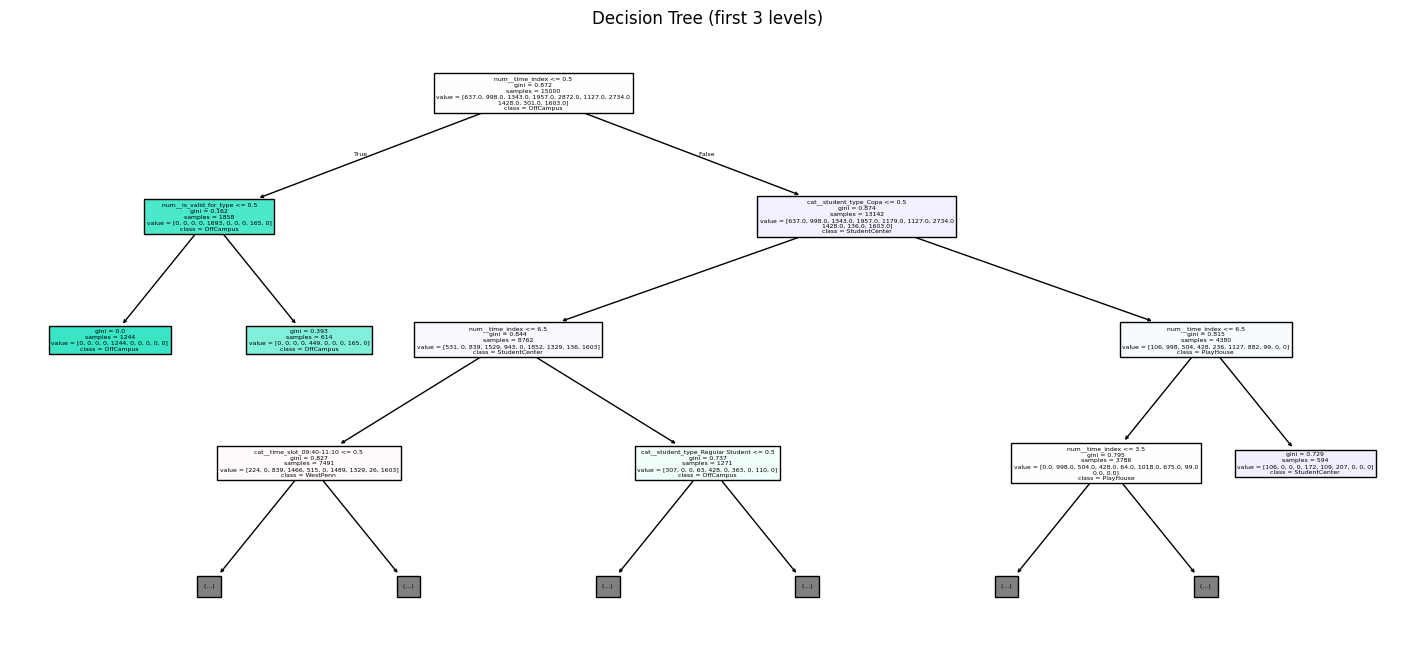


=== Tuned Decision Tree ===
Best params: {'model__max_depth': 12, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV Macro-F1: 0.3248
Val Accuracy: 0.4286
Val Macro-F1: 0.3266

=== Tuned Logistic Regression ===
Best params: {'model__C': 0.1}
Best CV Macro-F1: 0.309
Val Accuracy: 0.4148
Val Macro-F1: 0.3199

=== Tuned kNN ===
Best params: {'model__n_neighbors': 15, 'model__weights': 'uniform'}
Best CV Macro-F1: 0.2976
Val Accuracy: 0.4088
Val Macro-F1: 0.3219


/Users/juanbarrera/Documents/2026/SpringSemester/AdvancedTopicsInAI/Hw1/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/juanbarrera/Documents/2026/SpringSemester/AdvancedTopicsInAI/Hw1/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/juanbarrera/Documents/2026/SpringSemester/AdvancedTopicsInAI/Hw1/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate t


=== Tuned Random Forest ===
Best params: {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV Macro-F1: 0.3304
Val Accuracy: 0.4312
Val Macro-F1: 0.3319


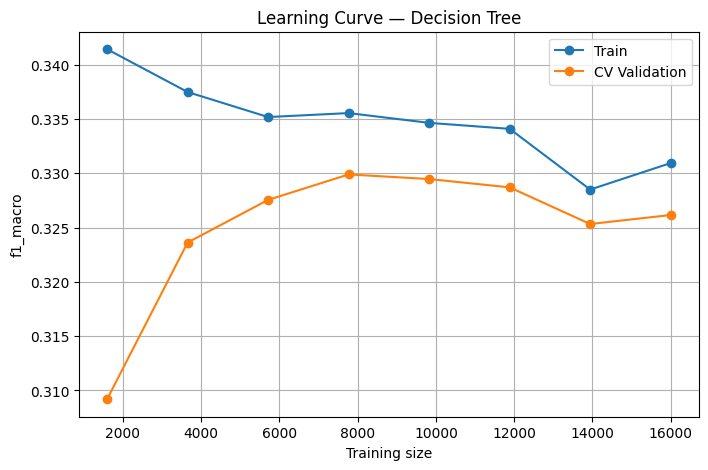

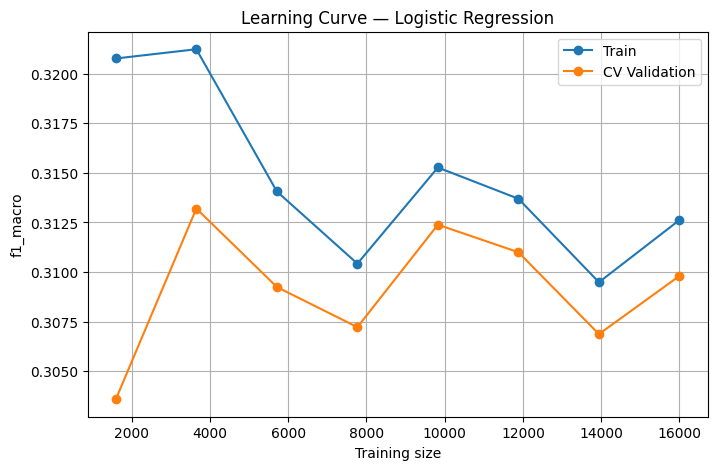

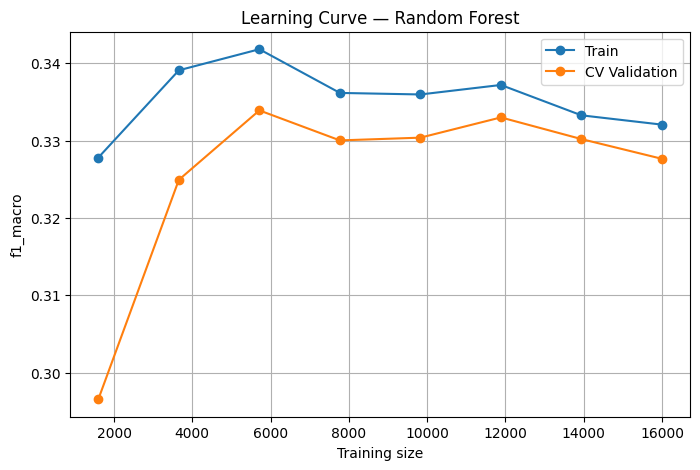


=== Validation Comparison ===
                 Model  Val_Accuracy  Val_Macro_F1  Val_LogLoss
4  RandomForest(Tuned)        0.4312      0.331870     1.224876
1  DecisionTree(Tuned)        0.4286      0.326592     1.199363
3           kNN(Tuned)        0.4088      0.321882     2.844623
2        LogReg(Tuned)        0.4148      0.319916     1.337300
0             Baseline        0.1916      0.032158    29.137689

Selected model: RandomForest(Tuned)

=== Final Test Evaluation ===
Best model: RandomForest(Tuned)
Test Accuracy: 0.4252
Test Macro-F1: 0.3338

Classification Report:
                      precision    recall  f1-score   support

BoulevardAppartments       0.00      0.00      0.00       212
    BoulevardStudios       0.34      0.41      0.38       333
        LawrenceHall       0.35      0.64      0.45       448
             Library       0.29      0.29      0.29       652
           OffCampus       0.77      0.67      0.71       957
           PlayHouse       0.37      0.42   

/Users/juanbarrera/Documents/2026/SpringSemester/AdvancedTopicsInAI/Hw1/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juanbarrera/Documents/2026/SpringSemester/AdvancedTopicsInAI/Hw1/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juanbarrera/Documents/2026/SpringSemester/AdvancedTopicsInAI/Hw1/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in lab

In [1]:
# ============================================================
# MODULE 5 — Complete Machine Learning System
# Goal:
# Predict the probability that a selected student type is at a
# selected main/inner location at a selected time.
#
# Strategy:
# 1) Train supervised models to predict MAIN LOCATION
#    P(main_location | student_type, time_slot, derived features)
# 2) Estimate conditional distributions:
#    P(inner_location | main_location, student_type, time_slot)
# 3) Final frontend probability:
#    P(main, inner | type, time)
#      = P(main | type, time) * P(inner | main, type, time)
#
# Parts covered:
# Part 1: Learning setup
# Part 2: Decision tree
# Part 3: Model selection
# Part 4: Learning theory analysis
# Part 5: Model variety
# Part 6: Ensemble learning
# Part 7: System design
# ============================================================

import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss
)

# ----------------------------
# Reproducibility
# ----------------------------

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ----------------------------
# Frontend schema (final target schema)
# ----------------------------

STUDENT_TYPES = [
    "Regular Student",
    "Copa",
    "Athlete"
]

TIME_SLOTS = [
    "07:00-08:00",
    "08:00-09:30",
    "09:40-11:10",
    "11:20-12:50",
    "13:00-14:30",
    "15:00-15:30",
    "16:00-17:30",
    "18:00-21:00"
]

LOCATION_HIERARCHY = {
    "LawrenceHall": [
        "DanceStudios",
        "DiningHall",
        "CopaTrainers",
        "HarryPotterRoom"
    ],
    "ThayerHall": [
        "RegularClassroom",
        "ComputerLab"
    ],
    "WestPenn": [
        "AnimationStudio",
        "ScreenWritingStudio",
        "RegularClassroom"
    ],
    "StudentCenter": [
        "Gym",
        "AthleteTrainers",
        "GameRoom",
        "CareerCenter"
    ],
    "Library": [
        "StudyRooms"
    ],
    "VillagePark": [
        "VillagePark"
    ],
    "PlayHouse": [
        "ActingStudios",
        "FilmStudios"
    ],
    "BoulevardStudios": [
        "BoulevardStudios"
    ],
    "BoulevardAppartments": [
        "MusicalTheaterStudios"
    ],
    "OffCampus": [
        "OffCampus"
    ]
}

MAIN_LOCATIONS = list(LOCATION_HIERARCHY.keys())

ALL_INNER_LOCATIONS = [
    inner
    for inner_list in LOCATION_HIERARCHY.values()
    for inner in inner_list
]

# ----------------------------
# Synthetic world model for data generation
# (This is your "ground truth" simulator for supervised learning)
# ----------------------------

# Main-location weights by (student_type, time_slot)
# These reflect your project logic and frontend time slots.
MAIN_LOCATION_WEIGHTS = {
    "Athlete": {
        "07:00-08:00": {
            "OffCampus": 5,
            "VillagePark": 2
        },
        "08:00-09:30": {

            "StudentCenter": 4,
            "LawrenceHall": 3,
            "Library": 2,
            "OffCampus": 1
        },
        "09:40-11:10": {
            "ThayerHall": 4,
            "WestPenn": 4,
            "Library": 2,
            "OffCampus": 1
        },
        "11:20-12:50": {
            "LawrenceHall": 5,
            "OffCampus": 4,
            "BoulevardAppartments": 3,
            "Library": 2,
            "VillagePark": 1
        },
        "13:00-14:30": {
            "ThayerHall": 4,
            "WestPenn": 4,
            "Library": 2,
            "OffCampus": 1
        },
        "15:00-15:30": {
            "StudentCenter": 5,
            "WestPenn": 2,
            "Library": 1
        },
        "16:00-17:30": {
            "LawrenceHall": 5,
            "WestPenn": 3,
            "StudentCenter": 2,
            "OffCampus": 1
        },
        "18:00-21:00": {
            "StudentCenter": 4,
            "OffCampus": 3,
            "BoulevardAppartments": 2,
            "VillagePark": 2
        }
    },

    "Copa": {
        "07:00-08:00": {
            "OffCampus": 10
        },
        "08:00-09:30": {
            "LawrenceHall": 3,
            "PlayHouse": 3,
            "BoulevardStudios": 3,
            "StudentCenter": 1,
            "OffCampus": 1
        },
        "09:40-11:10": {
            "BoulevardStudios": 4,
            "PlayHouse": 3,
            "LawrenceHall": 2,
            "StudentCenter": 2,
            "Library": 1
        },
        "11:20-12:50": {
            "LawrenceHall": 4,
            "StudentCenter": 3,
            "Library": 2,
            "PlayHouse": 2,
            "BoulevardStudios": 1
        },
        "13:00-14:30": {
            "BoulevardStudios": 4,
            "ThayerHall": 2,
            "PlayHouse": 3,
            "Library": 2,
            "StudentCenter": 1
        },
        "15:00-15:30": {
            "PlayHouse": 3,
            "StudentCenter": 2,
            "Library": 2,
            "BoulevardStudios": 3
        },
        "16:00-17:30": {
            "PlayHouse": 4,
            "StudentCenter": 3,
            "BoulevardStudios": 3,
            "Library": 1
        },
        "18:00-21:00": {
            "StudentCenter": 3,
            "OffCampus": 3,
            "BoulevardAppartments": 2,
            "PlayHouse": 2
        }
    },

    "Regular Student": {
        "07:00-08:00": {
            "OffCampus": 10
        },
        "08:00-09:30": {
            "ThayerHall": 4,
            "WestPenn": 3,
            "Library": 2,
            "StudentCenter": 1
        },
        "09:40-11:10": {
            "ThayerHall": 4,
            "WestPenn": 4,
            "Library": 2,
            "StudentCenter": 1
        },
        "11:20-12:50": {
            "LawrenceHall": 3,
            "StudentCenter": 3,
            "Library": 3,
            "ThayerHall": 1,
            "WestPenn": 1
        },
        "13:00-14:30": {
            "ThayerHall": 3,
            "WestPenn": 3,
            "Library": 3,
            "StudentCenter": 2
        },
        "15:00-15:30": {
            "StudentCenter": 3,
            "Library": 3,
            "ThayerHall": 2,
            "WestPenn": 2
        },
        "16:00-17:30": {
            "StudentCenter": 3,
            "Library": 3,
            "BoulevardAppartments": 2,
            "OffCampus": 2,
            "WestPenn": 1
        },
        "18:00-21:00": {
            "OffCampus": 4,
            "BoulevardAppartments": 3,
            "StudentCenter": 2,
            "Library": 1
        }
    }
}

# Inner-location conditional distributions
# P(inner | main, type, time)
# If a combination is not specified, fallback to uniform over inner rooms.
INNER_LOCATION_WEIGHTS = {
    "Athlete": {
        "StudentCenter": {
            "Gym": 4,
            "AthleteTrainers": 3,
            "GameRoom": 1,
            "CareerCenter": 1
        },
        "LawrenceHall": {
            "DiningHall": 4,
            "HarryPotterRoom": 1,
            "DanceStudios": 1,
            "CopaTrainers": 1
        },
        "Library": {
            "StudyRooms": 1
        },
        "VillagePark": {
            "VillagePark": 1
        },
        "PlayHouse": {
            "ActingStudios": 1,
            "FilmStudios": 1
        },
        "BoulevardStudios": {
            "BoulevardStudios": 1
        },
        "BoulevardAppartments": {
            "MusicalTheaterStudios": 1
        },
        "ThayerHall": {
            "RegularClassroom": 2,
            "ComputerLab": 1
        },
        "WestPenn": {
            "RegularClassroom": 2,
            "AnimationStudio": 1,
            "ScreenWritingStudio": 1
        },
        "OffCampus": {
            "OffCampus": 1
        }
    },

    "Copa": {
        "LawrenceHall": {
            "DanceStudios": 4,
            "DiningHall": 2,
            "CopaTrainers": 3,
            "HarryPotterRoom": 1
        },
        "PlayHouse": {
            "ActingStudios": 4,
            "FilmStudios": 3
        },
        "BoulevardStudios": {
            "BoulevardStudios": 1
        },
        "StudentCenter": {
            "CareerCenter": 2,
            "GameRoom": 2,
            "Gym": 1,
            "AthleteTrainers": 1
        },
        "BoulevardAppartments": {
            "MusicalTheaterStudios": 1
        },
        "Library": {
            "StudyRooms": 1
        },
        "ThayerHall": {
            "RegularClassroom": 1,
            "ComputerLab": 1
        },
        "WestPenn": {
            "AnimationStudio": 2,
            "ScreenWritingStudio": 3,
            "RegularClassroom": 1
        },
        "VillagePark": {
            "VillagePark": 1
        },
        "OffCampus": {
            "OffCampus": 1
        }
    },

    "Regular Student": {
        "ThayerHall": {
            "RegularClassroom": 4,
            "ComputerLab": 3
        },
        "WestPenn": {
            "RegularClassroom": 4,
            "AnimationStudio": 1,
            "ScreenWritingStudio": 1
        },
        "StudentCenter": {
            "GameRoom": 3,
            "CareerCenter": 2,
            "Gym": 1,
            "AthleteTrainers": 1
        },
        "Library": {
            "StudyRooms": 1
        },
        "LawrenceHall": {
            "DiningHall": 3,
            "HarryPotterRoom": 1,
            "DanceStudios": 1,
            "CopaTrainers": 1
        },
        "BoulevardAppartments": {
            "MusicalTheaterStudios": 1
        },
        "VillagePark": {
            "VillagePark": 1
        },
        "PlayHouse": {
            "ActingStudios": 1,
            "FilmStudios": 1
        },
        "BoulevardStudios": {
            "BoulevardStudios": 1
        },
        "OffCampus": {
            "OffCampus": 1
        }
    }
}

def weighted_choice(weight_dict: dict, rng: random.Random) -> str:
    items = [(k, v) for k, v in weight_dict.items() if v > 0]
    total = sum(v for _, v in items)
    r = rng.uniform(0, total)
    upto = 0.0
    for key, w in items:
        upto += w
        if upto >= r:
            return key
    return items[-1][0]

def sample_main_location(student_type: str, time_slot: str, rng: random.Random) -> str:
    weights = MAIN_LOCATION_WEIGHTS[student_type][time_slot]
    return weighted_choice(weights, rng)

def sample_inner_location(student_type: str, time_slot: str, main_location: str, rng: random.Random) -> str:
    if student_type in INNER_LOCATION_WEIGHTS and main_location in INNER_LOCATION_WEIGHTS[student_type]:
        weights = INNER_LOCATION_WEIGHTS[student_type][main_location]
        return weighted_choice(weights, rng)
    # fallback: uniform over building rooms
    choices = LOCATION_HIERARCHY[main_location]
    return rng.choice(choices)

# ----------------------------
# Data generation
# ----------------------------

def generate_dataset(n_samples: int = 25000, seed: int = 7) -> pd.DataFrame:
    rng = random.Random(seed)
    rows = []

    for _ in range(n_samples):
        student_type = rng.choice(STUDENT_TYPES)
        time_slot = rng.choice(TIME_SLOTS)

        main_location = sample_main_location(student_type, time_slot, rng)
        inner_location = sample_inner_location(student_type, time_slot, main_location, rng)

        # Derived features for learning
        time_index = TIME_SLOTS.index(time_slot)
        is_early_athlete_hour = int(time_slot == "07:00-08:00")
        is_valid_for_type = int(
            not (time_slot == "07:00-08:00" and student_type != "Athlete")
        )

        rows.append({
            "student_type": student_type,
            "time_slot": time_slot,
            "time_index": time_index,
            "is_early_athlete_hour": is_early_athlete_hour,
            "is_valid_for_type": is_valid_for_type,
            "main_location": main_location,
            "inner_location": inner_location,
        })

    return pd.DataFrame(rows)

df = generate_dataset(n_samples=25000, seed=RANDOM_SEED)

print("Dataset shape:", df.shape)
print("\nSample rows:")
print(df.head())

print("\nMain-location class distribution:")
print(df["main_location"].value_counts())

# ----------------------------
# Part 1: Learning Setup (19.1–19.2)
# Define features and labels
# ----------------------------

# Supervised target:
# Predict MAIN LOCATION from student type + time features
feature_cols = [
    "student_type",
    "time_slot",
    "time_index",
    "is_early_athlete_hour",
    "is_valid_for_type"
]

X = df[feature_cols]
y = df["main_location"]

# train/val/test split
X_trainval, X_test, y_trainval, y_test, df_trainval, df_test = train_test_split(
    X, y, df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

X_train, X_val, y_train, y_val, df_train, df_val = train_test_split(
    X_trainval, y_trainval, df_trainval,
    test_size=0.25,   # gives 60/20/20 overall
    random_state=RANDOM_SEED,
    stratify=y_trainval
)

print("\nSplit sizes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

categorical_features = ["student_type", "time_slot"]
numeric_features = ["time_index", "is_early_athlete_hour", "is_valid_for_type"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Baseline supervised model
baseline = Pipeline([
    ("prep", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED))
])

baseline.fit(X_train, y_train)
y_val_pred_base = baseline.predict(X_val)

print("\n=== Baseline model ===")
print("Val Accuracy:", round(accuracy_score(y_val, y_val_pred_base), 4))
print("Val Macro-F1:", round(f1_score(y_val, y_val_pred_base, average="macro"), 4))

# ----------------------------
# Part 2: Decision Tree Model (19.3)
# ----------------------------

tree = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(random_state=RANDOM_SEED))
])

tree.fit(X_train, y_train)
y_val_tree = tree.predict(X_val)

print("\n=== Decision Tree (default) ===")
print("Val Accuracy:", round(accuracy_score(y_val, y_val_tree), 4))
print("Val Macro-F1:", round(f1_score(y_val, y_val_tree, average="macro"), 4))

# visualize tree (first few levels)
plt.figure(figsize=(18, 8))
plot_tree(
    tree.named_steps["model"],
    feature_names=tree.named_steps["prep"].get_feature_names_out(),
    class_names=sorted(y.unique()),
    filled=True,
    max_depth=3
)
plt.title("Decision Tree (first 3 levels)")
plt.show()

# ----------------------------
# Part 3: Model Selection (19.4)
# Tune hyperparameters and compare with validation
# ----------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Decision Tree tuning
tree_grid = {
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

tree_search = GridSearchCV(
    Pipeline([
        ("prep", preprocess),
        ("model", DecisionTreeClassifier(random_state=RANDOM_SEED))
    ]),
    tree_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
tree_search.fit(X_train, y_train)
best_tree = tree_search.best_estimator_

print("\n=== Tuned Decision Tree ===")
print("Best params:", tree_search.best_params_)
print("Best CV Macro-F1:", round(tree_search.best_score_, 4))

y_val_tree_tuned = best_tree.predict(X_val)
print("Val Accuracy:", round(accuracy_score(y_val, y_val_tree_tuned), 4))
print("Val Macro-F1:", round(f1_score(y_val, y_val_tree_tuned, average="macro"), 4))

# ----------------------------
# Part 5: Model Variety (19.6–19.7)
# Linear model + nonparametric model
# ----------------------------

# Linear model: Logistic Regression
logreg = Pipeline([
    ("prep", preprocess),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
    max_iter=3000,
    random_state=RANDOM_SEED
))
])

logreg_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

logreg_search = GridSearchCV(
    logreg,
    logreg_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
logreg_search.fit(X_train, y_train)
best_logreg = logreg_search.best_estimator_

print("\n=== Tuned Logistic Regression ===")
print("Best params:", logreg_search.best_params_)
print("Best CV Macro-F1:", round(logreg_search.best_score_, 4))

y_val_logreg = best_logreg.predict(X_val)
print("Val Accuracy:", round(accuracy_score(y_val, y_val_logreg), 4))
print("Val Macro-F1:", round(f1_score(y_val, y_val_logreg, average="macro"), 4))

# Nonparametric model: kNN
knn = Pipeline([
    ("prep", preprocess),
    ("scale", StandardScaler(with_mean=False)),
    ("model", KNeighborsClassifier())
])

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 11, 15],
    "model__weights": ["uniform", "distance"]
}

knn_search = GridSearchCV(
    knn,
    knn_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_

print("\n=== Tuned kNN ===")
print("Best params:", knn_search.best_params_)
print("Best CV Macro-F1:", round(knn_search.best_score_, 4))

y_val_knn = best_knn.predict(X_val)
print("Val Accuracy:", round(accuracy_score(y_val, y_val_knn), 4))
print("Val Macro-F1:", round(f1_score(y_val, y_val_knn, average="macro"), 4))

# ----------------------------
# Part 6: Ensemble Learning (19.8)
# ----------------------------

rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

rf_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = GridSearchCV(
    rf,
    rf_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("\n=== Tuned Random Forest ===")
print("Best params:", rf_search.best_params_)
print("Best CV Macro-F1:", round(rf_search.best_score_, 4))

y_val_rf = best_rf.predict(X_val)
print("Val Accuracy:", round(accuracy_score(y_val, y_val_rf), 4))
print("Val Macro-F1:", round(f1_score(y_val, y_val_rf, average="macro"), 4))

# ----------------------------
# Part 4: Learning Theory Analysis (19.5)
# Analyze generalization behavior / bias-variance
# ----------------------------

def plot_learning_curve(estimator, title, X_data, y_data, scoring="f1_macro"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X_data,
        y_data,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring=scoring,
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Train")
    plt.plot(train_sizes, val_mean, marker="o", label="CV Validation")
    plt.title(title)
    plt.xlabel("Training size")
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(True)
    plt.show()

# Learning curves for bias/variance discussion
plot_learning_curve(best_tree, "Learning Curve — Decision Tree", X_trainval, y_trainval)
plot_learning_curve(best_logreg, "Learning Curve — Logistic Regression", X_trainval, y_trainval)
plot_learning_curve(best_rf, "Learning Curve — Random Forest", X_trainval, y_trainval)

# ----------------------------
# Compare all models on validation
# ----------------------------

models = {
    "Baseline": baseline,
    "DecisionTree(Tuned)": best_tree,
    "LogReg(Tuned)": best_logreg,
    "kNN(Tuned)": best_knn,
    "RandomForest(Tuned)": best_rf
}

val_rows = []
for name, model in models.items():
    y_pred = model.predict(X_val)

    row = {
        "Model": name,
        "Val_Accuracy": accuracy_score(y_val, y_pred),
        "Val_Macro_F1": f1_score(y_val, y_pred, average="macro")
    }

    # Log loss only if predict_proba is available
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)
        row["Val_LogLoss"] = log_loss(y_val, y_prob, labels=model.classes_)
    else:
        row["Val_LogLoss"] = np.nan

    val_rows.append(row)

val_results = pd.DataFrame(val_rows).sort_values(by="Val_Macro_F1", ascending=False)
print("\n=== Validation Comparison ===")
print(val_results)

best_model_name = val_results.iloc[0]["Model"]
best_model = models[best_model_name]
print("\nSelected model:", best_model_name)

# ----------------------------
# Retrain selected model on full train+val
# ----------------------------

best_model.fit(X_trainval, y_trainval)

# ----------------------------
# Final test evaluation
# ----------------------------

y_test_pred = best_model.predict(X_test)

print("\n=== Final Test Evaluation ===")
print("Best model:", best_model_name)
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("Test Macro-F1:", round(f1_score(y_test, y_test_pred, average="macro"), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# ----------------------------
# Inner-location conditional probabilities
# P(inner | main, student_type, time_slot)
# Estimated from TRAINING data only
# ----------------------------

def estimate_inner_conditionals(df_source: pd.DataFrame) -> dict:
    """
    Returns nested dictionary:
    cond[student_type][time_slot][main_location][inner_location] = probability
    """
    cond = defaultdict(
        lambda: defaultdict(
            lambda: defaultdict(dict)
        )
    )

    grouped = df_source.groupby(["student_type", "time_slot", "main_location"])

    for (stype, time_slot, main_loc), group in grouped:
        counts = group["inner_location"].value_counts(normalize=True)
        cond[stype][time_slot][main_loc] = counts.to_dict()

    return cond

inner_conditional_probs = estimate_inner_conditionals(df_trainval)

# ----------------------------
# Frontend-facing query function
# ----------------------------

def predict_location_probability(
    student_type: str,
    main_location: str,
    inner_location: str,
    time_slot: str,
    trained_model,
    inner_conditionals: dict
) -> dict:
    """
    Returns:
      P(main | type,time)
      P(inner | main,type,time)
      P(main, inner | type,time) = product
    """
    # Basic validation
    if student_type not in STUDENT_TYPES:
        raise ValueError(f"Unknown student type: {student_type}")
    if main_location not in MAIN_LOCATIONS:
        raise ValueError(f"Unknown main location: {main_location}")
    if inner_location not in LOCATION_HIERARCHY[main_location]:
        raise ValueError(f"{inner_location} is not inside {main_location}")
    if time_slot not in TIME_SLOTS:
        raise ValueError(f"Unknown time slot: {time_slot}")

    query_df = pd.DataFrame([{
        "student_type": student_type,
        "time_slot": time_slot,
        "time_index": TIME_SLOTS.index(time_slot),
        "is_early_athlete_hour": int(time_slot == "07:00-08:00"),
        "is_valid_for_type": int(
            not (time_slot == "07:00-08:00" and student_type != "Athlete")
        )
    }])

    # Main-location probability from trained ML model
    if not hasattr(trained_model, "predict_proba"):
        raise ValueError("Selected model does not support probability outputs")

    probs = trained_model.predict_proba(query_df)[0]
    classes = trained_model.classes_
    main_prob_map = dict(zip(classes, probs))
    p_main = main_prob_map.get(main_location, 0.0)

    # Inner conditional probability from empirical training distribution
    p_inner_given_main = (
        inner_conditionals
        .get(student_type, {})
        .get(time_slot, {})
        .get(main_location, {})
        .get(inner_location, 0.0)
    )

    # Fallback if no empirical match exists
    if p_inner_given_main == 0.0:
        room_count = len(LOCATION_HIERARCHY[main_location])
        p_inner_given_main = 1.0 / room_count

    joint_prob = p_main * p_inner_given_main

    return {
        "student_type": student_type,
        "time_slot": time_slot,
        "main_location": main_location,
        "inner_location": inner_location,
        "p_main": p_main,
        "p_inner_given_main": p_inner_given_main,
        "p_main_and_inner": joint_prob
    }

# ----------------------------
# Example frontend-like queries
# ----------------------------

print("\n=== Example Frontend Queries ===")

example_queries = [
    ("Athlete", "StudentCenter", "Gym", "16:00-17:30"),
    ("Copa", "PlayHouse", "ActingStudios", "16:00-17:30"),
    ("Regular Student", "ThayerHall", "ComputerLab", "09:40-11:10"),
    ("Athlete", "VillagePark", "VillagePark", "07:00-08:00"),
]

for q in example_queries:
    result = predict_location_probability(
        student_type=q[0],
        main_location=q[1],
        inner_location=q[2],
        time_slot=q[3],
        trained_model=best_model,
        inner_conditionals=inner_conditional_probs
    )

    print("\nQuery:", q)
    print(f"P(main={result['main_location']} | type,time) = {result['p_main']:.4f}")
    print(f"P(inner={result['inner_location']} | main,type,time) = {result['p_inner_given_main']:.4f}")
    print(f"P(main & inner | type,time) = {result['p_main_and_inner']:.4f}")

# ----------------------------
# Part 7: System Design (19.9)
# Full ML pipeline + deployment considerations
# ----------------------------

print("\n\n--- Markdown-ready explanation (paste into notebook) ---\n")
print("""
### Part 1 (Learning Setup)
- **Supervised learning problem**:
  predict the **main campus location** of a student given:
  - student type
  - time slot
  - derived time-validity features
- **Features**:
  - student_type
  - time_slot
  - time_index
  - is_early_athlete_hour
  - is_valid_for_type
- **Label**:
  - main_location
- **Baseline model**:
  - DummyClassifier using the most frequent class

### Part 2 (Decision Tree Model)
- A decision tree classifier was trained to predict main location.
- The first levels of the tree can be interpreted directly, showing how student type and time split the data.

### Part 3 (Model Selection)
- Hyperparameters were tuned using validation / cross-validation.
- Decision Tree, Logistic Regression, kNN, and Random Forest were compared using:
  - Accuracy
  - Macro-F1
  - Log Loss (when probabilities were available)

### Part 4 (Learning Theory Analysis)
- Learning curves were used to analyze generalization behavior.
- A deep tree may overfit (low bias, high variance).
- Logistic Regression may underfit more easily (higher bias, lower variance).
- Random Forest generally reduces variance compared to a single tree.

### Part 5 (Model Variety)
- **Linear model**: Logistic Regression
- **Nonparametric model**: k-Nearest Neighbors
- **Tree model**: Decision Tree

### Part 6 (Ensemble Learning)
- **Ensemble model**: Random Forest
- This model combines many trees and often improves generalization and stability.

### Part 7 (System Design)
- The final frontend query is:
  (student_type, main_location, inner_location, time_slot)
- The ML model predicts:
  P(main_location | student_type, time_slot)
- Inner locations are handled using conditional distributions:
  P(inner_location | main_location, student_type, time_slot)
- Final probability shown to the user is:
  P(main, inner | type, time)
  = P(main | type, time) * P(inner | main, type, time)

### Deployment considerations
- The model can be exposed through an API endpoint.
- Frontend dropdowns should use the exact canonical values for:
  - student type
  - main location
  - inner location
  - time slot
- Input validation should reject invalid combinations, such as:
  - non-Athlete at 07:00-08:00
- For production use, the model and conditional inner-location tables should be serialized and loaded once at server startup.
""".strip())